sklearn.datasetsモジュールのmake_blobs関数を使い、random_state=52（特に数字に意味はありません）にしてデータを生成しグラフ化してみましょう。そこからクラスタリングをしてください。いくつのグループに分けますか。
また分けた後は、クラスター番号がわかるように色分けして、グラフ化してください。

In [1]:
# データ加工・処理・分析ライブラリ
import numpy as np
import numpy.random as random
import scipy as sp
from pandas import Series, DataFrame
import pandas as pd
# 可視化ライブラリ
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline
# 機械学習ライブラリ
import sklearn
# 小数第 3 位まで表示
%precision 3

'%.3f'

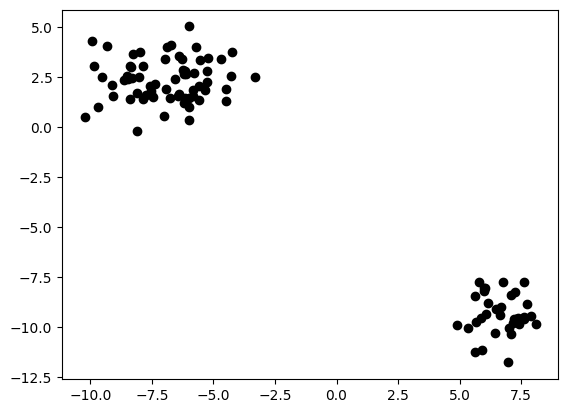

In [3]:
# k-means 法を使うためのインポート
from sklearn.cluster import KMeans
# データ取得のためのインポート
from sklearn.datasets import make_blobs
# サンプルデータ生成
# 注意：make_blobs は 2 つの値を返すため、一方は使用しない「 _ 」で受け取る
X, _ = make_blobs(random_state=52)
# グラフを描画
# color のオプションで色付けができる
plt.scatter(X[:,0],X[:,1],color='black')

In [5]:
# KMeans クラスの初期化
kmeans = KMeans(init='random',n_clusters=2)
# クラスターの重心を計算
kmeans.fit(X)
# クラスター番号を予測
y_pred = kmeans.predict(X)

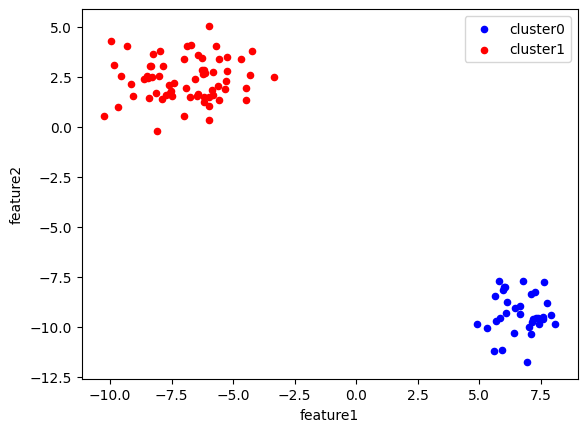

In [6]:
# concat でデータを横に結合 (axis=1 を指定 )
merge_data = pd.concat([pd.DataFrame(X[:,0]), pd.DataFrame(X[:,1]), pd.DataFrame(y_pred)], axis=1)
# 上記のデータにて、X 軸を feature1、Y 軸を feature2、クラスター番号を cluster と列名指定
merge_data.columns = ['feature1','feature2','cluster']
# クラスタリング結果のグラフ化
ax = None
colors = ['blue', 'red', 'green']
for i, data in merge_data.groupby('cluster'):
    ax = data.plot.scatter(x='feature1', y='feature2', color=colors[i], label=f'cluster{i}', ax=ax)

Text(0, 0.5, 'Distortion')

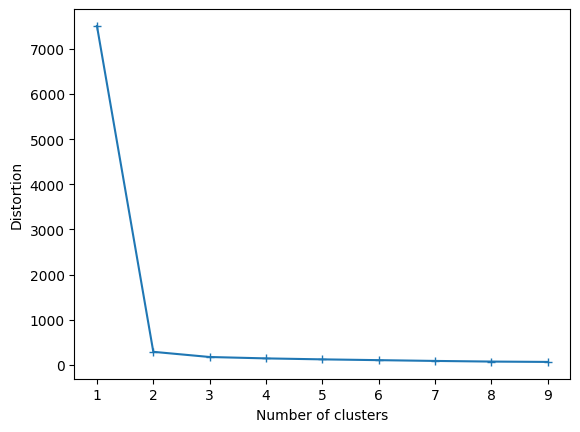

In [7]:
# エルボー方による推定。クラスター数を 1 から 10 に増やして、それぞれの距離の総和を求める
dist_list =[]
for i in range(1,10):
    kmeans= KMeans(n_clusters=i, init='random', random_state=0)
    kmeans.fit(X)
    dist_list.append(kmeans.inertia_)
# グラフを表示
plt.plot(range(1,10), dist_list,marker='+')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')